# Locking-Parameter Optimization Test

Test both optimization approaches and compare their objective curves.

- **Approach 1** (F=always, R=configurable): Every loop runs simulation; retrain every N loops
- **Approach 2** (R=always, inner loop): Algorithm runs fast surrogate-only inner loop; simulation + retrain each outer loop

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from mpbax.core.model import DummyModel
from engine import LockingEngine
from algorithm import LockingAlgorithm
from oracles import LockingOracle
from utils.calc import calc_objective

## Helper: Run optimization and collect results

In [ ]:
def run_optimization(approach, max_loops=10, retrain_every=3, inner_steps=10,
                     input_dim=4, n_initial=200, seed=42, run_name=None):
    """Run locking optimization and return per-loop results.
    
    Checkpoints are saved to runs/<run_name>/ for inspection.
    """
    oracle = LockingOracle(use_surrogate_init=True, noise_scale=0.01)

    # Persistent checkpoint directory
    if run_name is None:
        run_name = f"approach{approach}_rt{retrain_every}_is{inner_steps}"
    checkpoint_dir = str(Path('runs') / run_name)
    Path(checkpoint_dir).mkdir(parents=True, exist_ok=True)

    config = {
        'seed': seed,
        'max_loops': max_loops,
        'locking': {
            'approach': approach,
            'retrain_every': retrain_every,
        },
        'checkpoint': {'dir': checkpoint_dir, 'freq': 1},
        'training': {'mode': 'finetune', 'checkpoint_mode': 'final'},
        'oracles': [{
            'name': 'locking',
            'input_dim': input_dim,
            'n_initial': n_initial,
            'function': {'class': oracle},
            'model': {'class': DummyModel},
        }],
        'algorithm': {
            'class': LockingAlgorithm,
            'params': {
                'input_dims': [input_dim],
                'n_propose': 5,
                'n_candidates': 500,
                'approach': approach,
                'inner_steps': inner_steps,
            },
        },
    }

    engine = LockingEngine(config)
    oracle.engine = engine
    engine.run()

    # Collect per-loop objectives from checkpoint data
    loop_results = []
    from mpbax.core.data_handler import DataHandler

    for loop in range(max_loops):
        data_path = Path(checkpoint_dir) / 'locking' / f'data_{loop}.pkl'
        if data_path.exists():
            dh = DataHandler.load(str(data_path))
            D, L_star = dh.get_data()
            if D is not None:
                objs = calc_objective(D, L_star)
                loop_results.append({
                    'loop': loop,
                    'n_samples': len(D),
                    'mean_obj': np.mean(objs),
                    'min_obj': np.min(objs),
                    'best_D': D[np.argmin(objs)],
                    'best_L': L_star[np.argmin(objs)],
                })

    # Also compute running best (cumulative min across all loops)
    running_best = []
    best_so_far = float('inf')
    for r in loop_results:
        best_so_far = min(best_so_far, r['min_obj'])
        running_best.append(best_so_far)

    print(f"  Checkpoints saved to: {checkpoint_dir}")
    return loop_results, running_best

## Run Approach 1 (F=always, R=every 3 loops)

In [3]:
results_a1, running_best_a1 = run_optimization(
    approach=1, max_loops=10, retrain_every=3
)

print("\nApproach 1 summary:")
print(f"{'Loop':>4} {'Samples':>8} {'Mean Obj':>10} {'Min Obj':>10} {'Best So Far':>12}")
print("-" * 50)
for r, rb in zip(results_a1, running_best_a1):
    print(f"{r['loop']:4d} {r['n_samples']:8d} {r['mean_obj']:10.4f} {r['min_obj']:10.4f} {rb:12.4f}")

Initializing fresh run...
Generating initial data for locking...

=== Loop 0 ===
  [R switch] Retraining at loop 0
Training models...
Saving model checkpoint at loop 0...

Loop 0 summary:
  locking: 200 evaluations

=== Loop 1 ===
Proposing new candidates...
  [Algorithm] Approach 1: evaluated 500 candidates, proposing 5 (best obj=0.2898)
  [R switch] Skipping retrain (next at loop 3)
Saving model checkpoint at loop 1...

Loop 1 summary:
  locking: 205 evaluations

=== Loop 2 ===
Proposing new candidates...
  [Algorithm] Approach 1: evaluated 500 candidates, proposing 5 (best obj=0.2978)
  [R switch] Skipping retrain (next at loop 3)
Saving model checkpoint at loop 2...

Loop 2 summary:
  locking: 210 evaluations

=== Loop 3 ===
Proposing new candidates...
  [Algorithm] Approach 1: evaluated 500 candidates, proposing 5 (best obj=0.2973)
  [R switch] Retraining at loop 3
Training models...
Saving model checkpoint at loop 3...

Loop 3 summary:
  locking: 215 evaluations

=== Loop 4 ===
P

## Run Approach 2 (R=always, inner loop=10 steps)

In [4]:
results_a2, running_best_a2 = run_optimization(
    approach=2, max_loops=10, inner_steps=10
)

print("\nApproach 2 summary:")
print(f"{'Loop':>4} {'Samples':>8} {'Mean Obj':>10} {'Min Obj':>10} {'Best So Far':>12}")
print("-" * 50)
for r, rb in zip(results_a2, running_best_a2):
    print(f"{r['loop']:4d} {r['n_samples']:8d} {r['mean_obj']:10.4f} {r['min_obj']:10.4f} {rb:12.4f}")

Initializing fresh run...
Generating initial data for locking...

=== Loop 0 ===
Training models...
Saving model checkpoint at loop 0...

Loop 0 summary:
  locking: 200 evaluations

=== Loop 1 ===
Proposing new candidates...
  [Algorithm] Approach 2: 10 inner steps, best obj=0.2864
Training models...
Saving model checkpoint at loop 1...

Loop 1 summary:
  locking: 205 evaluations

=== Loop 2 ===
Proposing new candidates...
  [Algorithm] Approach 2: 10 inner steps, best obj=0.2832
Training models...
Saving model checkpoint at loop 2...

Loop 2 summary:
  locking: 210 evaluations

=== Loop 3 ===
Proposing new candidates...
  [Algorithm] Approach 2: 10 inner steps, best obj=0.2757
Training models...
Saving model checkpoint at loop 3...

Loop 3 summary:
  locking: 215 evaluations

=== Loop 4 ===
Proposing new candidates...
  [Algorithm] Approach 2: 10 inner steps, best obj=0.2722
Training models...
Saving model checkpoint at loop 4...

Loop 4 summary:
  locking: 220 evaluations

=== Loop 5

## Compare Objective Curves

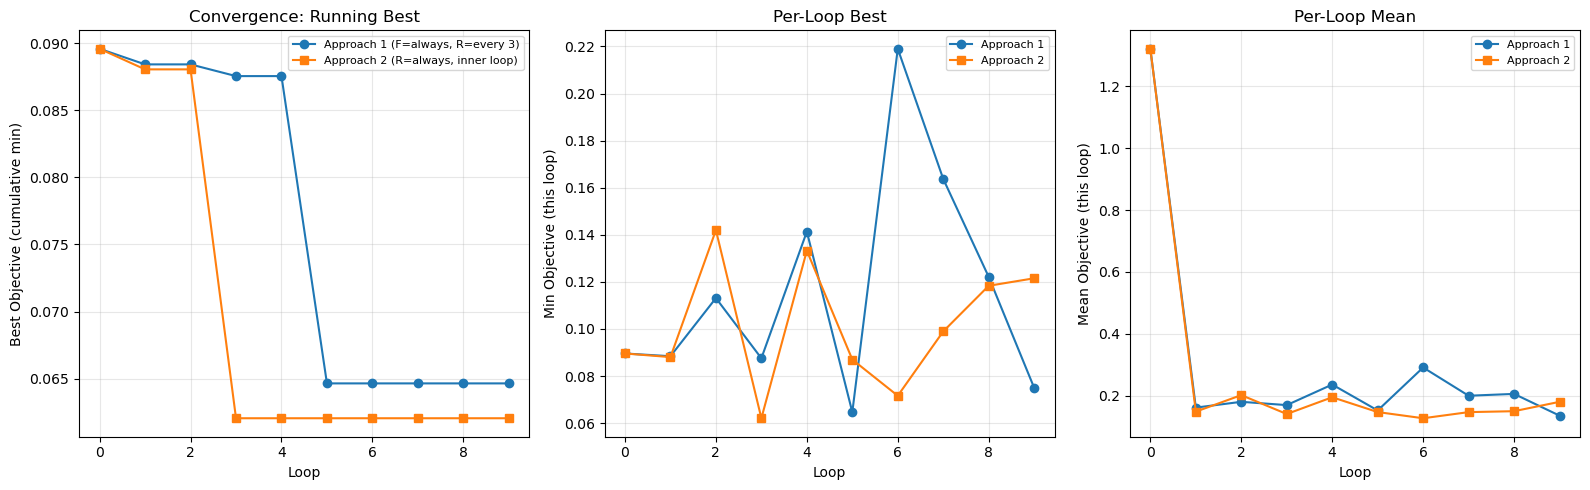

Saved: locking_comparison.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

loops_a1 = [r['loop'] for r in results_a1]
loops_a2 = [r['loop'] for r in results_a2]

# --- Plot 1: Running best objective ---
ax = axes[0]
ax.plot(loops_a1, running_best_a1, 'o-', label='Approach 1 (F=always, R=every 3)', color='tab:blue')
ax.plot(loops_a2, running_best_a2, 's-', label='Approach 2 (R=always, inner loop)', color='tab:orange')
ax.set_xlabel('Loop')
ax.set_ylabel('Best Objective (cumulative min)')
ax.set_title('Convergence: Running Best')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 2: Per-loop min objective ---
ax = axes[1]
ax.plot(loops_a1, [r['min_obj'] for r in results_a1], 'o-', label='Approach 1', color='tab:blue')
ax.plot(loops_a2, [r['min_obj'] for r in results_a2], 's-', label='Approach 2', color='tab:orange')
ax.set_xlabel('Loop')
ax.set_ylabel('Min Objective (this loop)')
ax.set_title('Per-Loop Best')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# --- Plot 3: Per-loop mean objective ---
ax = axes[2]
ax.plot(loops_a1, [r['mean_obj'] for r in results_a1], 'o-', label='Approach 1', color='tab:blue')
ax.plot(loops_a2, [r['mean_obj'] for r in results_a2], 's-', label='Approach 2', color='tab:orange')
ax.set_xlabel('Loop')
ax.set_ylabel('Mean Objective (this loop)')
ax.set_title('Per-Loop Mean')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('locking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: locking_comparison.png")

## Sensitivity: Vary R switch frequency (Approach 1)

Running Approach 1 with retrain_every=1...
Initializing fresh run...
Generating initial data for locking...

=== Loop 0 ===
Training models...
Saving model checkpoint at loop 0...

Loop 0 summary:
  locking: 200 evaluations

=== Loop 1 ===
Proposing new candidates...
  [Algorithm] Approach 1: evaluated 500 candidates, proposing 5 (best obj=0.2898)
Training models...
Saving model checkpoint at loop 1...

Loop 1 summary:
  locking: 205 evaluations

=== Loop 2 ===
Proposing new candidates...
  [Algorithm] Approach 1: evaluated 500 candidates, proposing 5 (best obj=0.2918)
Training models...
Saving model checkpoint at loop 2...

Loop 2 summary:
  locking: 210 evaluations

=== Loop 3 ===
Proposing new candidates...
  [Algorithm] Approach 1: evaluated 500 candidates, proposing 5 (best obj=0.2862)
Training models...
Saving model checkpoint at loop 3...

Loop 3 summary:
  locking: 215 evaluations

=== Loop 4 ===
Proposing new candidates...
  [Algorithm] Approach 1: evaluated 500 candidates, pr

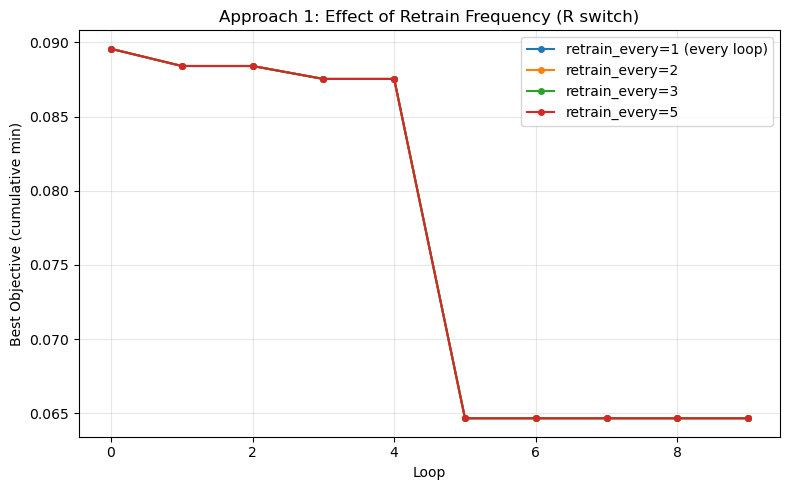

Saved: r_switch_sensitivity.png


In [6]:
retrain_configs = [1, 2, 3, 5]  # retrain every N loops
a1_variants = {}

for rt in retrain_configs:
    print(f"Running Approach 1 with retrain_every={rt}...")
    results, running_best = run_optimization(
        approach=1, max_loops=10, retrain_every=rt
    )
    a1_variants[rt] = (results, running_best)

fig, ax = plt.subplots(figsize=(8, 5))
for rt, (results, running_best) in a1_variants.items():
    loops = [r['loop'] for r in results]
    label = f'retrain_every={rt}' + (' (every loop)' if rt == 1 else '')
    ax.plot(loops, running_best, 'o-', label=label, markersize=4)

ax.set_xlabel('Loop')
ax.set_ylabel('Best Objective (cumulative min)')
ax.set_title('Approach 1: Effect of Retrain Frequency (R switch)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('r_switch_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: r_switch_sensitivity.png")

## Sensitivity: Vary inner steps (Approach 2)

Running Approach 2 with inner_steps=1...
Initializing fresh run...
Generating initial data for locking...

=== Loop 0 ===
Training models...
Saving model checkpoint at loop 0...

Loop 0 summary:
  locking: 200 evaluations

=== Loop 1 ===
Proposing new candidates...
  [Algorithm] Approach 2: 1 inner steps, best obj=0.2898
Training models...
Saving model checkpoint at loop 1...

Loop 1 summary:
  locking: 205 evaluations

=== Loop 2 ===
Proposing new candidates...
  [Algorithm] Approach 2: 1 inner steps, best obj=0.2899
Training models...
Saving model checkpoint at loop 2...

Loop 2 summary:
  locking: 210 evaluations

=== Loop 3 ===
Proposing new candidates...
  [Algorithm] Approach 2: 1 inner steps, best obj=0.2857
Training models...
Saving model checkpoint at loop 3...

Loop 3 summary:
  locking: 215 evaluations

=== Loop 4 ===
Proposing new candidates...
  [Algorithm] Approach 2: 1 inner steps, best obj=0.2856
Training models...
Saving model checkpoint at loop 4...

Loop 4 summary:
 

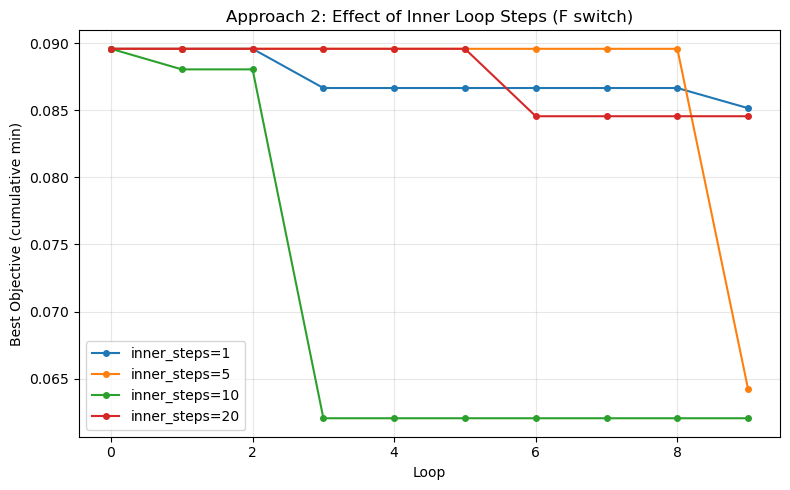

Saved: f_switch_sensitivity.png


In [7]:
inner_configs = [1, 5, 10, 20]
a2_variants = {}

for steps in inner_configs:
    print(f"Running Approach 2 with inner_steps={steps}...")
    results, running_best = run_optimization(
        approach=2, max_loops=10, inner_steps=steps
    )
    a2_variants[steps] = (results, running_best)

fig, ax = plt.subplots(figsize=(8, 5))
for steps, (results, running_best) in a2_variants.items():
    loops = [r['loop'] for r in results]
    ax.plot(loops, running_best, 'o-', label=f'inner_steps={steps}', markersize=4)

ax.set_xlabel('Loop')
ax.set_ylabel('Best Objective (cumulative min)')
ax.set_title('Approach 2: Effect of Inner Loop Steps (F switch)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('f_switch_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: f_switch_sensitivity.png")

## Summary

In [8]:
print("=" * 60)
print("Final Comparison")
print("=" * 60)
print(f"\n{'Config':<35} {'Final Best Obj':>15}")
print("-" * 50)

for rt, (_, rb) in a1_variants.items():
    print(f"Approach 1 (retrain_every={rt}){'':<10} {rb[-1]:>15.6f}")

for steps, (_, rb) in a2_variants.items():
    print(f"Approach 2 (inner_steps={steps}){'':<10} {rb[-1]:>15.6f}")

Final Comparison

Config                               Final Best Obj
--------------------------------------------------
Approach 1 (retrain_every=1)                  0.064656
Approach 1 (retrain_every=2)                  0.064656
Approach 1 (retrain_every=3)                  0.064656
Approach 1 (retrain_every=5)                  0.064656
Approach 2 (inner_steps=1)                  0.085152
Approach 2 (inner_steps=5)                  0.064209
Approach 2 (inner_steps=10)                  0.062060
Approach 2 (inner_steps=20)                  0.084552
